### 数据集

In [18]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("default")

In [19]:
w, b = 1.8, 2.5

In [20]:
np.random.seed(0)
x1 = np.random.rand(100) * 4
noise = np.random.randn(100)
x2 = w * x1 + b + noise

In [21]:
X = np.vstack([x1, x2]).T
X -= np.mean(X, axis=0)
X.shape

(100, 2)

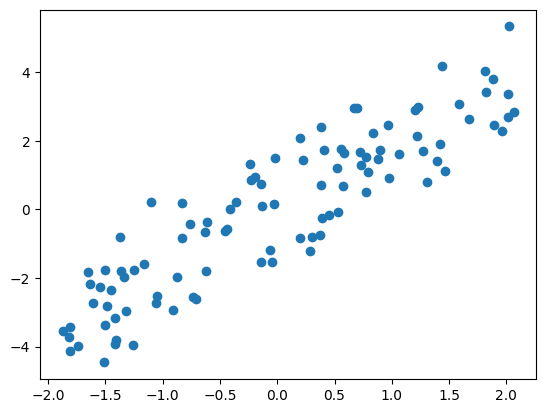

In [22]:
plt.scatter(X[:, 0], X[:, 1])
plt.show()

### PCA数据降噪
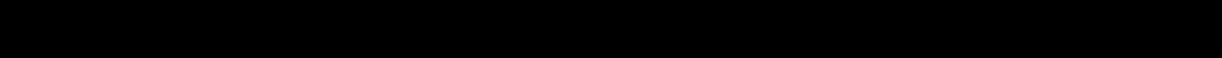

In [23]:
from sklearn.decomposition import PCA

In [24]:
pca = PCA(n_components=1)
pca.fit(X);

In [25]:
X_pca = pca.transform(X)  # 将原始二维数据投影到 1 维主成分空间
X_pca_inv = pca.inverse_transform(X_pca)  # 将降维后的数据近似还原回原始二维空间

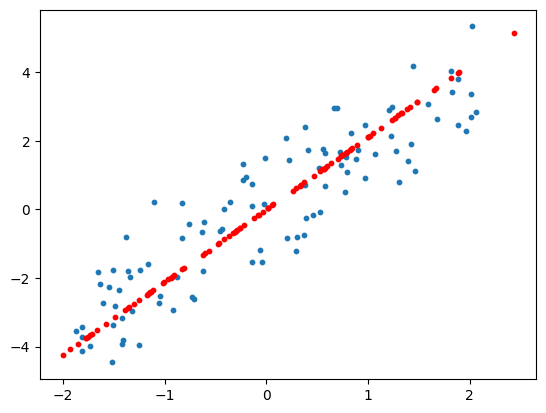

In [26]:
plt.scatter(X[:, 0], X[:, 1], s=10)
plt.scatter(X_pca_inv[:, 0], X_pca_inv[:, 1], s=10, c="r")
plt.show()

### 图像降噪

In [27]:
from sklearn.datasets import load_digits
digits = load_digits()  # 加载手写数字数据集
X = digits.data  # X：图像特征数据，每张图片被展开成 64 个特征（8×8）
y = digits.target  # y：每张图片对应的数字标签（0~9）

In [28]:
X.shape, y.shape

((1797, 64), (1797,))

In [29]:
# 把数据集中的前 20 个数字样本，按照 4 行 × 5 列的形式显示出来。
def plot_top20_digits(X):
    for i in range(20):
        plt.subplot(4, 5, i + 1)
        plt.xticks([])
        plt.yticks([])
        plt.imshow(X[i].reshape(8, 8), cmap=plt.cm.gray_r, interpolation="nearest")
    plt.show()

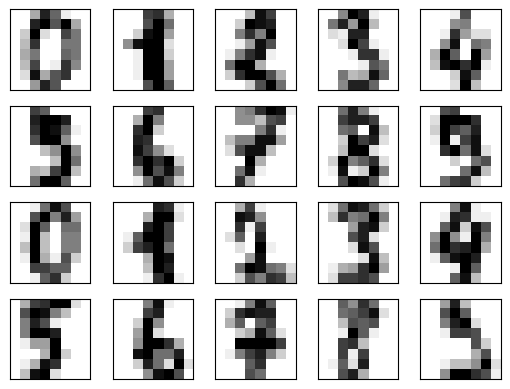

In [30]:
plot_top20_digits(X)  # 显示原始数据中的前 20 张手写数字图片

In [31]:
# 给原始图像数据加入随机高斯噪声，randn() 生成均值为 0、标准差为 1 的正态分布随机数，×3 用于增强噪声强度
np.random.seed(0)
X_noise = X + np.random.randn(X.shape[0], X.shape[1]) * 3

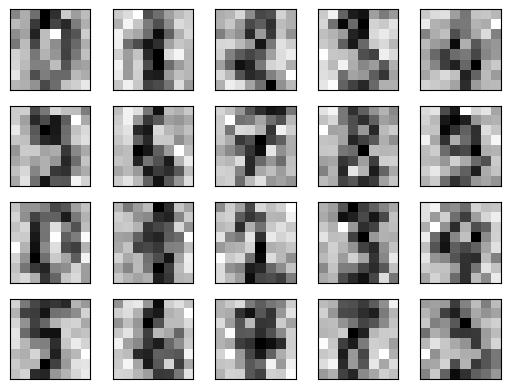

In [32]:
plot_top20_digits(X_noise)  # 显示加入噪声后的前 20 张图片

In [33]:
pca = PCA(0.5)    # 创建 PCA 模型，保留能够解释原始数据 50% 方差的主成分
pca.fit(X_noise)  # 使用带噪声的数据训练 PCA，学习主要的数据结构
X_noise_pca = pca.transform(X_noise)  # 将 64 维带噪数据映射到较低维的主成分空间
X_noise_inv = pca.inverse_transform(X_noise_pca)  # 将降维后的数据重新恢复到原来的 64 维空间

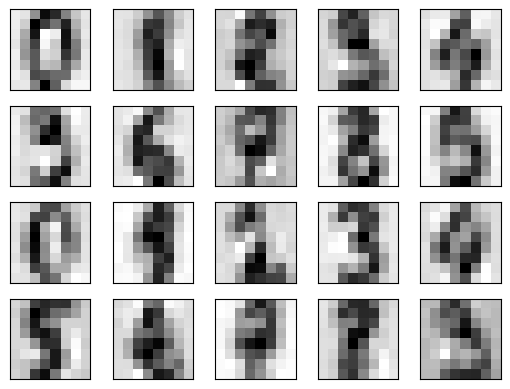

In [34]:
plot_top20_digits(X_noise_inv)  # 显示经过 PCA 降维并重构后的图像，与 X_noise 对比，可以观察 PCA 的降噪效果